# Install Libraries and Load Dataset

In [4]:
import sys
!{sys.executable} -m pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 756.9 kB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import joblib
from imblearn.over_sampling import SMOTE


df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Stage 1: Data Aquisition and Exploration

## Identify Missing Values in Each Column 

In [6]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (5110, 12)

Data Types:
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


# Stroke Distribution Between Those Who Do and Don't

Stroke distribution:
 0    4861
1     249
Name: stroke, dtype: int64

Class balance %:
 0    95.127202
1     4.872798
Name: stroke, dtype: float64


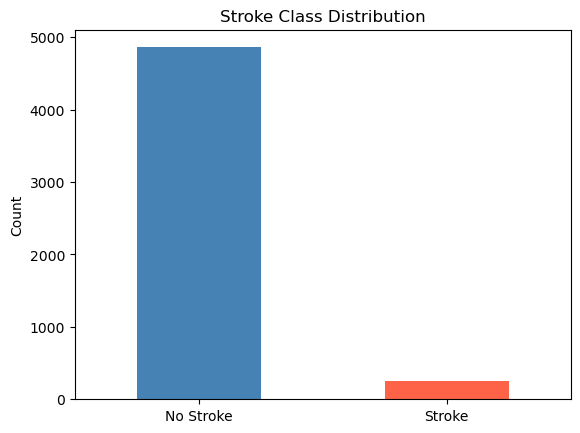

In [7]:
print("Stroke distribution:\n", df['stroke'].value_counts())
print("\nClass balance %:\n", df['stroke'].value_counts(normalize=True) * 100)

df['stroke'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Stroke Class Distribution')
plt.xticks([0,1], ['No Stroke', 'Stroke'], rotation=0)
plt.ylabel('Count')
plt.show()

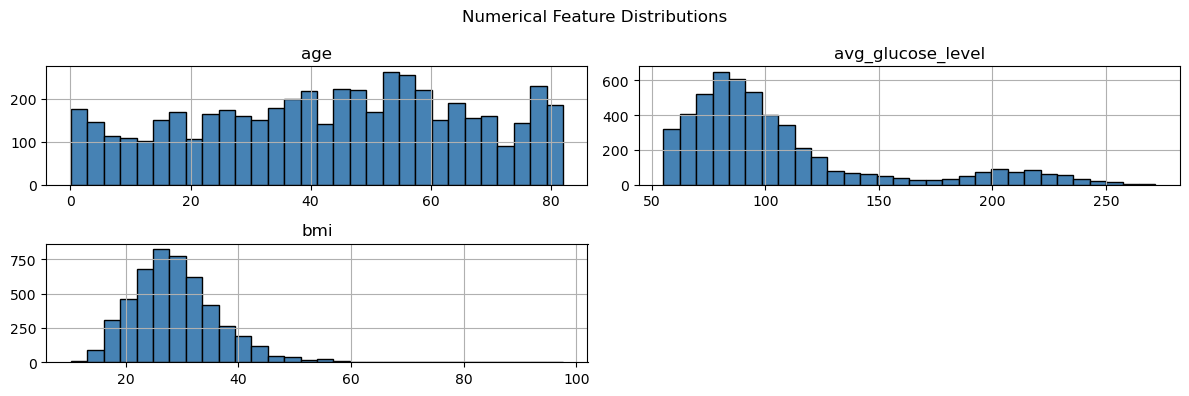

In [8]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
df[num_cols].hist(bins=30, figsize=(12,4), color='steelblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

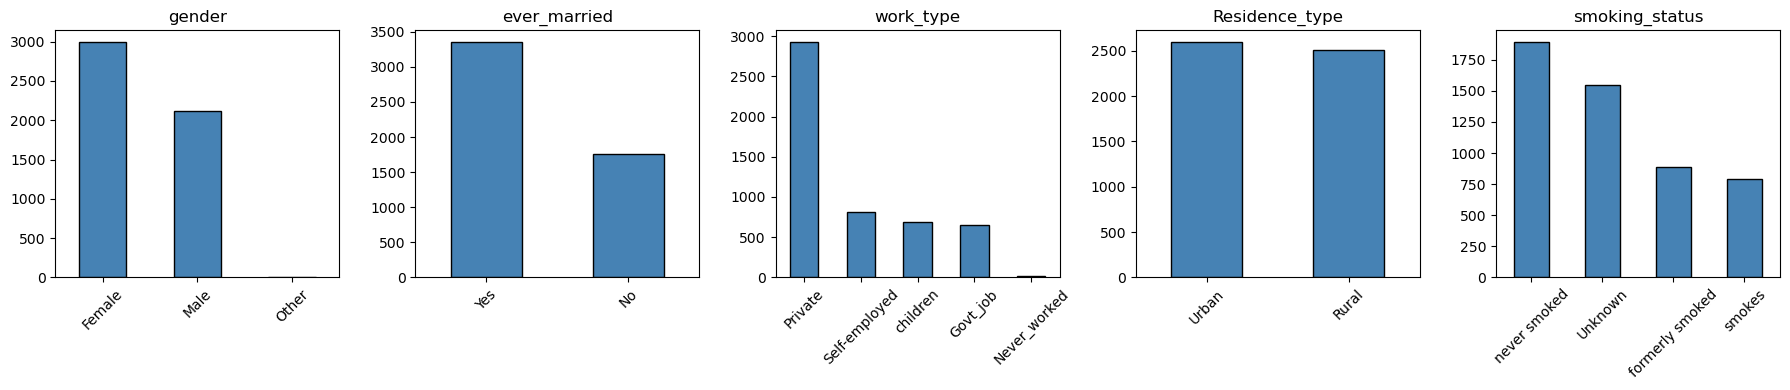

In [9]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

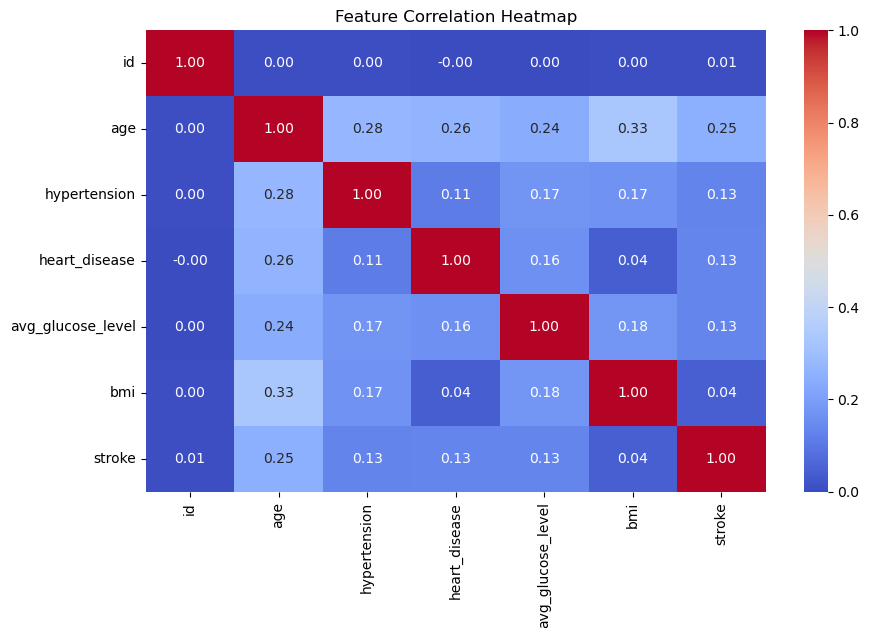

In [10]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
df_update = df.drop(columns=['id'])
df_update

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [12]:
df_update['bmi'] = df_update['bmi'].fillna(df_update['bmi'].median())
df_update

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [13]:
print("Shape:", df_update.shape)
print("\nData Types:\n", df_update.dtypes)
print("\nMissing Values:\n", df_update.isnull().sum())

Shape: (5110, 11)

Data Types:
 gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [14]:
unique_categories = df['gender'].unique()
print("Categories:", unique_categories)

print()

count_categories = df['gender'].value_counts()
print("Count Each Category:", count_categories)

Categories: ['Male' 'Female' 'Other']

Count Each Category: Female    2994
Male      2115
Other        1
Name: gender, dtype: int64


In [15]:
# Remove Rows with Gender as 'Other' since there's only one
df_update = df_update[df_update['gender'] != 'Other']
print("Shape after dropping 'Other' gender:", df_update.shape)

Shape after dropping 'Other' gender: (5109, 11)


In [16]:
# Label Encoder
le = LabelEncoder()

df_update['ever_married'] = le.fit_transform(df_update['ever_married'])
df_update['Residence_type'] = le.fit_transform(df_update['Residence_type'])
df_update['gender'] = le.fit_transform(df_update['gender'])

df_update[['ever_married', 'Residence_type', 'gender']].head()

/var/folders/wd/lt57_yyn45g245ppmr0_bk680000gn/T/ipykernel_19113/3587515243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_update['ever_married'] = le.fit_transform(df_update['ever_married'])
/var/folders/wd/lt57_yyn45g245ppmr0_bk680000gn/T/ipykernel_19113/3587515243.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_update['Residence_type'] = le.fit_transform(df_update['Residence_type'])
/var/folders/wd/lt57_yyn45g245ppmr0_bk680000gn/T/ipykernel_19113/3587515243.py:6: SettingWithCopyWarning: 
A

,ever_married,Residence_type,gender
0,1,1,1
1,1,0,0
2,1,0,1
3,1,1,0
4,1,0,0


In [17]:
print("Columns:", df_update.columns.tolist())

Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [18]:
df_update = pd.get_dummies(df_update, columns=['work_type', 'smoking_status'], drop_first=False)
print("Shape after one-hot encoding:", df_update.shape)
print("Columns:", df_update.columns.tolist())

Shape after one-hot encoding: (5109, 18)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [19]:
X = df_update.drop('stroke', axis=1) # Features everything but Stroke as this is our target
y = df_update['stroke'] # Target Variable

print("X shape:", X.shape) # Shape after removing target variable
print("y distribution:\n", y.value_counts()) # Distributin of target variable

X shape: (5109, 17)
y distribution:
 0    4860
1     249
Name: stroke, dtype: int64


In [20]:
scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
X[num_cols] = scaler.fit_transform(X[num_cols])

# Save scaler for use in backend later
import os
os.makedirs('../model', exist_ok=True)
joblib.dump(scaler, '../model/scaler.pkl')

print("Scaler saved!")
print(X.head())

Scaler saved!
   gender       age  hypertension  heart_disease  ever_married  \
0       1  1.051242             0              1             1   
1       0  0.785889             0              0             1   
2       1  1.626174             0              1             1   
3       0  0.255182             0              0             1   
4       0  1.581949             1              0             1   

   Residence_type  avg_glucose_level       bmi  work_type_Govt_job  \
0               1           2.706450  1.004893                   0   
1               0           2.121652 -0.099142                   0   
2               0          -0.004867  0.472358                   0   
3               1           1.437473  0.719142                   0   
4               0           1.501297 -0.631677                   0   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                       0                  1                        0   
1                     

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train: (4087, 17)
X_test: (1022, 17)
y_train distribution:
 0    3888
1     199
Name: stroke, dtype: int64
y_test distribution:
 0    972
1     50
Name: stroke, dtype: int64


In [22]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train_resampled:", X_train_resampled.shape)
print("y_train_resampled distribution:\n", pd.Series(y_train_resampled).value_counts())

After SMOTE:
X_train_resampled: (7776, 17)
y_train_resampled distribution:
 0    3888
1    3888
Name: stroke, dtype: int64


In [23]:
np.save('../model/X_train.npy', X_train_resampled)
np.save('../model/X_test.npy', X_test.values)
np.save('../model/y_train.npy', y_train_resampled)
np.save('../model/y_test.npy', y_test.values)

# Save feature column names for backend
joblib.dump(X.columns.tolist(), '../model/feature_columns.pkl')

print("All data saved!")
print("Feature columns:", X.columns.tolist())

All data saved!
Feature columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
